In [ ]:
!gdown 1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg






Downloading...
From: https://drive.google.com/uc?id=1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg
To: /content/AnomalyDetection.csv
100% 33.0k/33.0k [00:00<00:00, 54.9MB/s]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (12,8)

In [ ]:
df = pd.read_csv('/content/AnomalyDetection.csv')
df.head()

,Mileage,Price
0,54.282388,67.967708
1,17.331911,70.023637
2,36.548113,68.080455
3,42.567541,71.058755
4,5.608853,57.822432


In [ ]:
from sklearn.ensemble import IsolationForest
# contamination - what proportion of data you think are outliers
# contamination does NOT change how trees are built, it only affects:
# Where the cutoff is placed
# How many points are finally marked anomalous

model = IsolationForest(n_estimators=100)
model.fit(df)
df['anomaly_score'] = - model.score_samples(df)

In [ ]:
df['anomaly_score']

,anomaly_score
0,0.517289
1,0.428582
2,0.409520
3,0.419078
4,0.592435
...,...
903,0.721734
904,0.753388
905,0.749829
906,0.616119


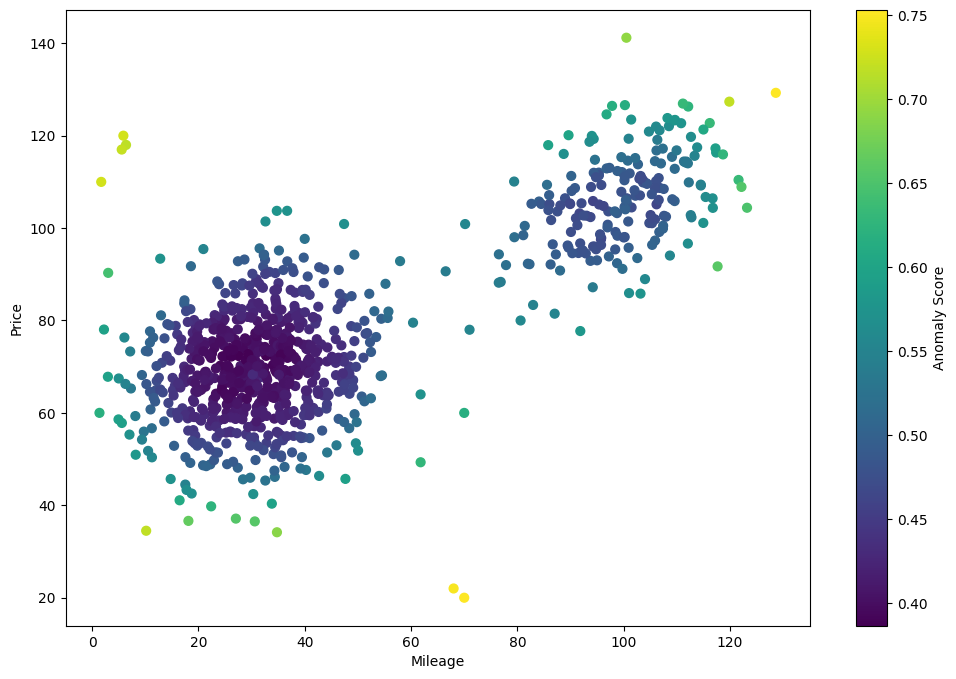

In [ ]:
plt.scatter(
    df.Mileage,
    df.Price,
    s=40,
    c=df['anomaly_score'],   # 👈 color by score
    cmap='viridis'           # optional but very useful
)

plt.colorbar(label='Anomaly Score')  # legend for colors
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

In [ ]:
from sklearn.svm import OneClassSVM
ocsvm = OneClassSVM(kernel = 'rbf',gamma = 0.001).fit_predict(df)
df['is_outlier_svm'] = ocsvm

/tmp/ipykernel_29066/1811901226.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


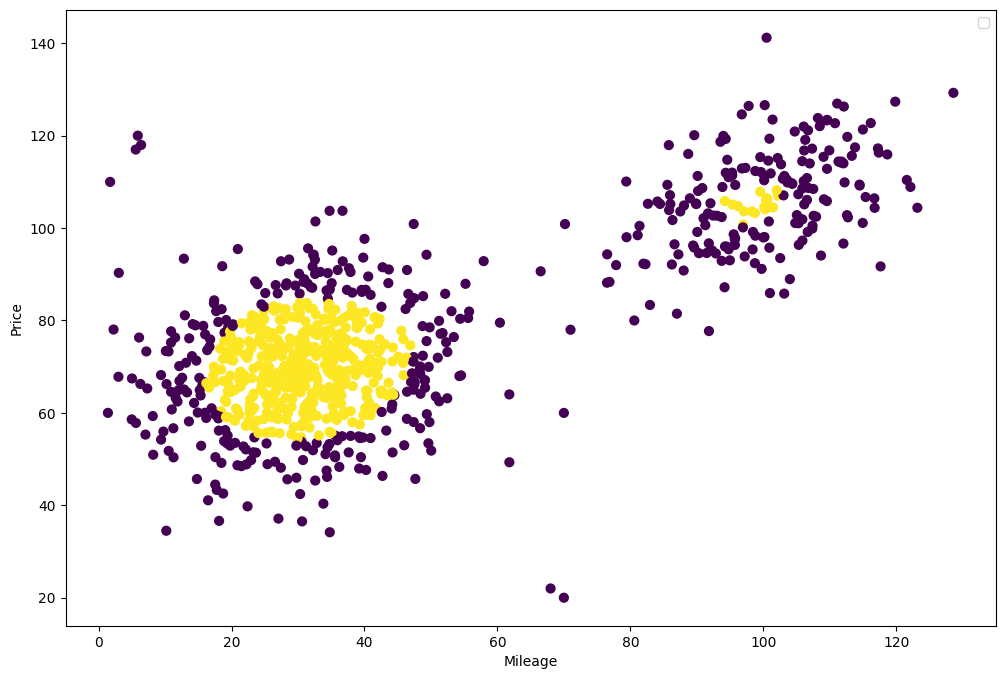

In [ ]:
plt.scatter(df['Mileage'], df['Price'], s=40, c=df['is_outlier_svm'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
# contamination - 5% as outliers
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof.fit(df.iloc[:, :2])

# LOF scores
df['lof_score'] = lof.negative_outlier_factor_

# Labels
df['is_outlier_lof'] = lof.fit_predict(df.iloc[:, :2])

In [ ]:
df

,Mileage,Price,anomaly_score,is_outlier_lof,lof_score
0,54.282388,67.967708,0.517289,1,-1.320438
1,17.331911,70.023637,0.428582,1,-1.016913
2,36.548113,68.080455,0.409520,1,-1.008251
3,42.567541,71.058755,0.419078,1,-1.002954
4,5.608853,57.822432,0.592435,1,-1.292697
...,...,...,...,...,...
903,5.584939,117.000000,0.721734,-1,-3.718057
904,70.000000,20.000000,0.753388,-1,-4.459373
905,68.000000,22.000000,0.749829,-1,-4.188359
906,70.000000,60.000000,0.616119,-1,-2.902858


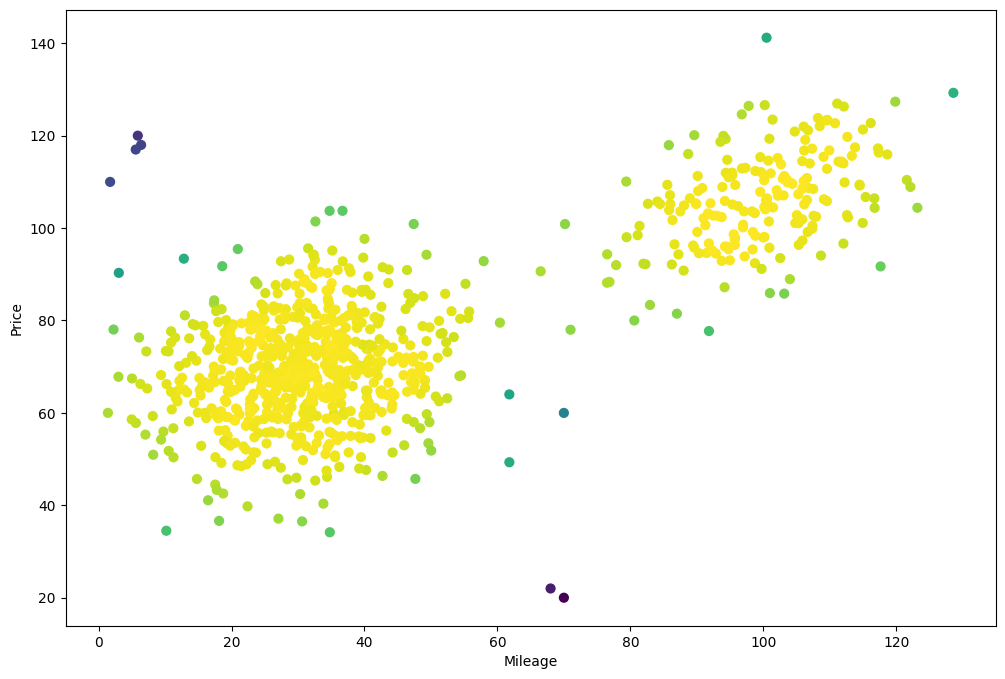

In [ ]:
plt.scatter(df.Mileage, df.Price, s=40, c=df['lof_score'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()